# Module 0

## Dataset: Child Mind Institute — Problematic Internet Use

Explore and analyse the dataset to understand its structure and key characteristics (describe
them); Conduct data pre-processing (i.e., encoding categorical variables, feature scaling,
missing values imputation); Create new variables if needed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 90)

df = pd.read_csv("../base_data/cmi_internet.csv")

# General info: dtypes and non-null counts
df.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 8460 entries, 0 to 8459
Data columns (total 82 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      8460 non-null   int64  
 1   Basic_Demos-Enroll_Season               8460 non-null   str    
 2   Basic_Demos-Age                         8460 non-null   int64  
 3   Basic_Demos-Sex                         8460 non-null   int64  
 4   CGAS-Season                             7158 non-null   str    
 5   CGAS-CGAS_Score                         7034 non-null   float64
 6   Physical-Season                         7858 non-null   str    
 7   Physical-BMI                            7591 non-null   float64
 8   Physical-Height                         7595 non-null   float64
 9   Physical-Weight                         7641 non-null   float64
 10  Physical-Waist_Circumference            5624 non-null   float64
 11  Ph

In [2]:
# Quick descriptive statistics for all numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,8460.0,4229.500000,2442.335972,0.0,2114.750000,4229.500000,6344.250000,8459.000000
Basic_Demos-Age,8460.0,10.240189,3.574680,5.0,7.000000,10.000000,12.000000,22.000000
Basic_Demos-Sex,8460.0,0.402364,0.490404,0.0,0.000000,0.000000,1.000000,1.000000
CGAS-CGAS_Score,7034.0,67.021041,35.284140,25.0,60.500000,65.000000,70.500000,999.000000
Physical-BMI,7591.0,19.532651,4.683925,0.0,16.541742,17.937682,21.469546,59.132048
...,...,...,...,...,...,...,...,...
PCIAT-PCIAT_Total,2714.0,27.855195,20.318784,0.0,12.000000,26.000000,41.000000,93.000000
SDS-SDS_Total_Raw,4903.0,41.410667,9.464932,17.0,35.000000,39.500000,45.000000,96.000000
SDS-SDS_Total_T,4903.0,58.072813,12.563287,38.0,50.000000,55.000000,62.500000,100.000000
PreInt_EduHx-computerinternet_hoursday,7849.0,0.981144,1.046645,0.0,0.000000,1.000000,2.000000,3.000000


---
## Step 1. Missing values Overview


We start by going over missing values in order to get an idea of what we're working with

In [3]:
# Missing values table (only columns with missingness)
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(1)
miss_df = (pd.DataFrame({"missing": miss, "pct": miss_pct})
             .query("missing > 0")
             .sort_values("pct", ascending=False))
miss_df

,missing,pct
PCIAT-PCIAT_18,5746,67.9
PCIAT-PCIAT_17,5746,67.9
PCIAT-PCIAT_16,5746,67.9
PCIAT-PCIAT_04,5746,67.9
PCIAT-PCIAT_03,5746,67.9
...,...,...
Physical-Weight,819,9.7
PreInt_EduHx-computerinternet_hoursday,611,7.2
Physical-Season,602,7.1
FGC-Season,569,6.7


77 of the columns present missing values, especially those that are in the PCIAT instrument.

This group of variables will be addressed first after data visualization, then moving on to the rest.

---
## Step 2. Data visualization

We explore each feature's distribution to spot outliers and wrong data.

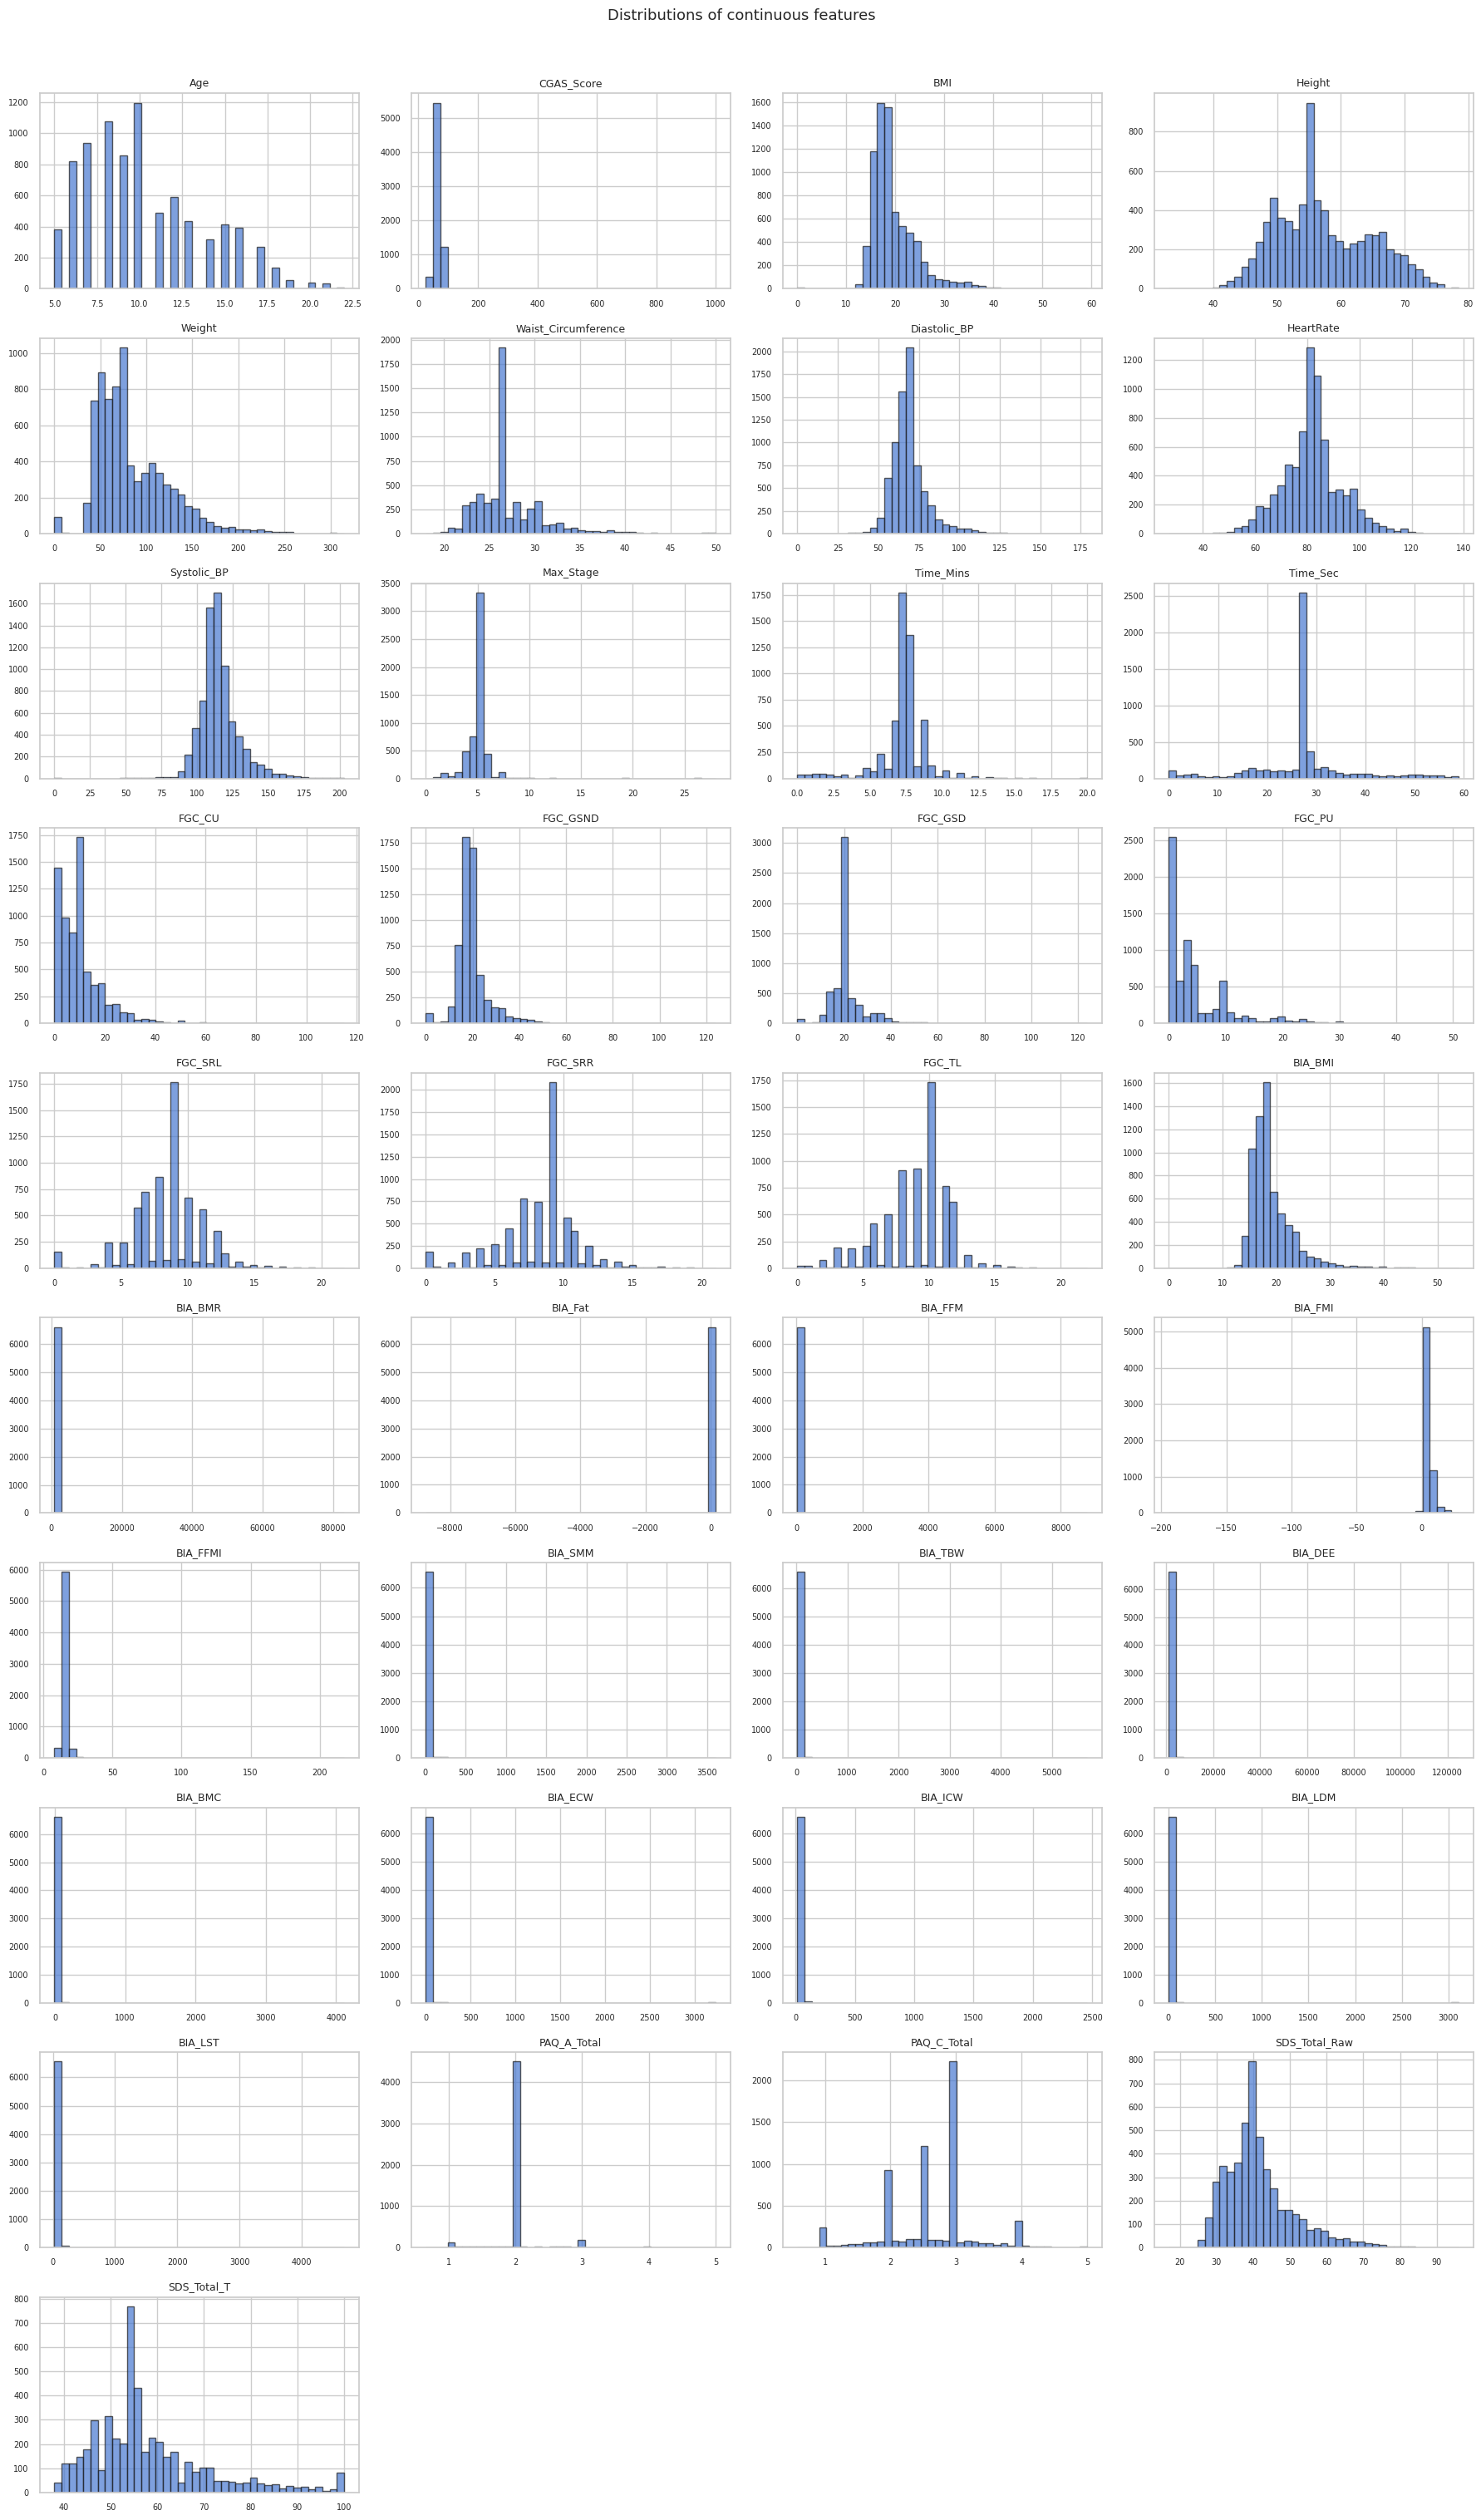

In [4]:
# Histograms of key continuous features (non-PCIAT, non-Season)
cont_cols = [
    "Basic_Demos-Age", "CGAS-CGAS_Score",
    "Physical-BMI", "Physical-Height", "Physical-Weight",
    "Physical-Waist_Circumference", "Physical-Diastolic_BP",
    "Physical-HeartRate", "Physical-Systolic_BP",
    "Fitness_Endurance-Max_Stage", "Fitness_Endurance-Time_Mins",
    "Fitness_Endurance-Time_Sec",
    "FGC-FGC_CU", "FGC-FGC_GSND", "FGC-FGC_GSD",
    "FGC-FGC_PU", "FGC-FGC_SRL", "FGC-FGC_SRR", "FGC-FGC_TL",
    "BIA-BIA_BMI", "BIA-BIA_BMR", "BIA-BIA_Fat", "BIA-BIA_FFM",
    "BIA-BIA_FMI", "BIA-BIA_FFMI", "BIA-BIA_SMM", "BIA-BIA_TBW",
    "BIA-BIA_DEE", "BIA-BIA_BMC", "BIA-BIA_ECW", "BIA-BIA_ICW",
    "BIA-BIA_LDM", "BIA-BIA_LST",
    "PAQ_A-PAQ_A_Total", "PAQ_C-PAQ_C_Total",
    "SDS-SDS_Total_Raw", "SDS-SDS_Total_T",
]

n = len(cont_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(cont_cols):
    df[col].dropna().hist(bins=40, ax=axes[i], edgecolor="k", alpha=0.7)
    axes[i].set_title(col.split("-")[-1], fontsize=9)
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Distributions of continuous features", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Observations on continuous features:
- CGAS_Score has a spike at 999, clearly an error, as scale is 1–100.
- Physical-BMI and Physical-Weight have values at exactly 0 which is biologically impossible, likely missing data encoded as zero.
- BIA features (BMR, FFM, DEE, ECW, etc.) show extreme right-tail outliers orders of magnitude above the median, possible measurement errors.
- BIA-BIA_Fat has negative values which is physically impossible for body fat percentage.

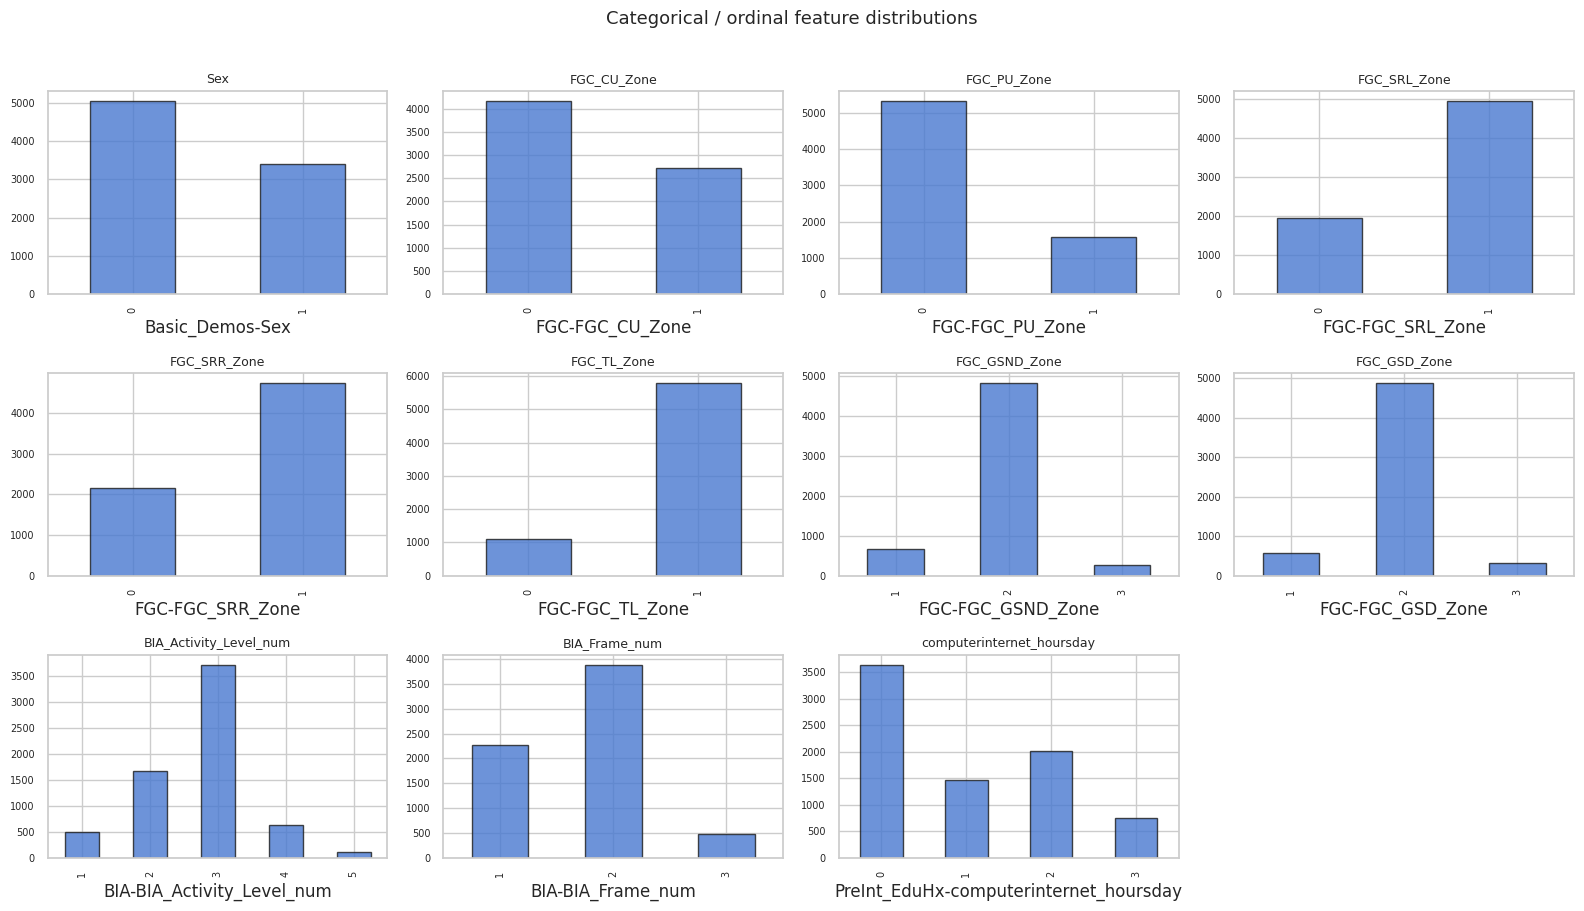

In [5]:
# Bar plots for categorical / ordinal features
cat_cols = [
    "Basic_Demos-Sex",
    "FGC-FGC_CU_Zone", "FGC-FGC_PU_Zone", "FGC-FGC_SRL_Zone",
    "FGC-FGC_SRR_Zone", "FGC-FGC_TL_Zone",
    "FGC-FGC_GSND_Zone", "FGC-FGC_GSD_Zone",
    "BIA-BIA_Activity_Level_num", "BIA-BIA_Frame_num",
    "PreInt_EduHx-computerinternet_hoursday",
]

fig, axes = plt.subplots(3, 4, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df[col].dropna().astype(int).value_counts().sort_index().plot.bar(
        ax=axes[i], edgecolor="k", alpha=0.8)
    axes[i].set_title(col.split("-")[-1], fontsize=9)
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Categorical / ordinal feature distributions", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Observations — categorical/ordinal features:
- Sex: 60% male, 40% female — moderate imbalance.
- Fitness zones (CU, PU, SRL, SRR, TL): most are binary (0 = Needs Improvement, 1 = Healthy). Push-up zone is heavily skewed toward 0 (most children need improvement), while Trunk Lift zone is heavily skewed toward 1 (most in healthy zone).
- Grip Strength zones (GSND, GSD): 3-level ordinal (Weak/Normal/Strong), concentrated around Normal (2).
- Activity Level (BIA): 5-level ordinal, peaks at levels 2–3 (Light/Moderate).
- Internet hours/day: ordinal 0–3, majority at 0 (< 1h/day).

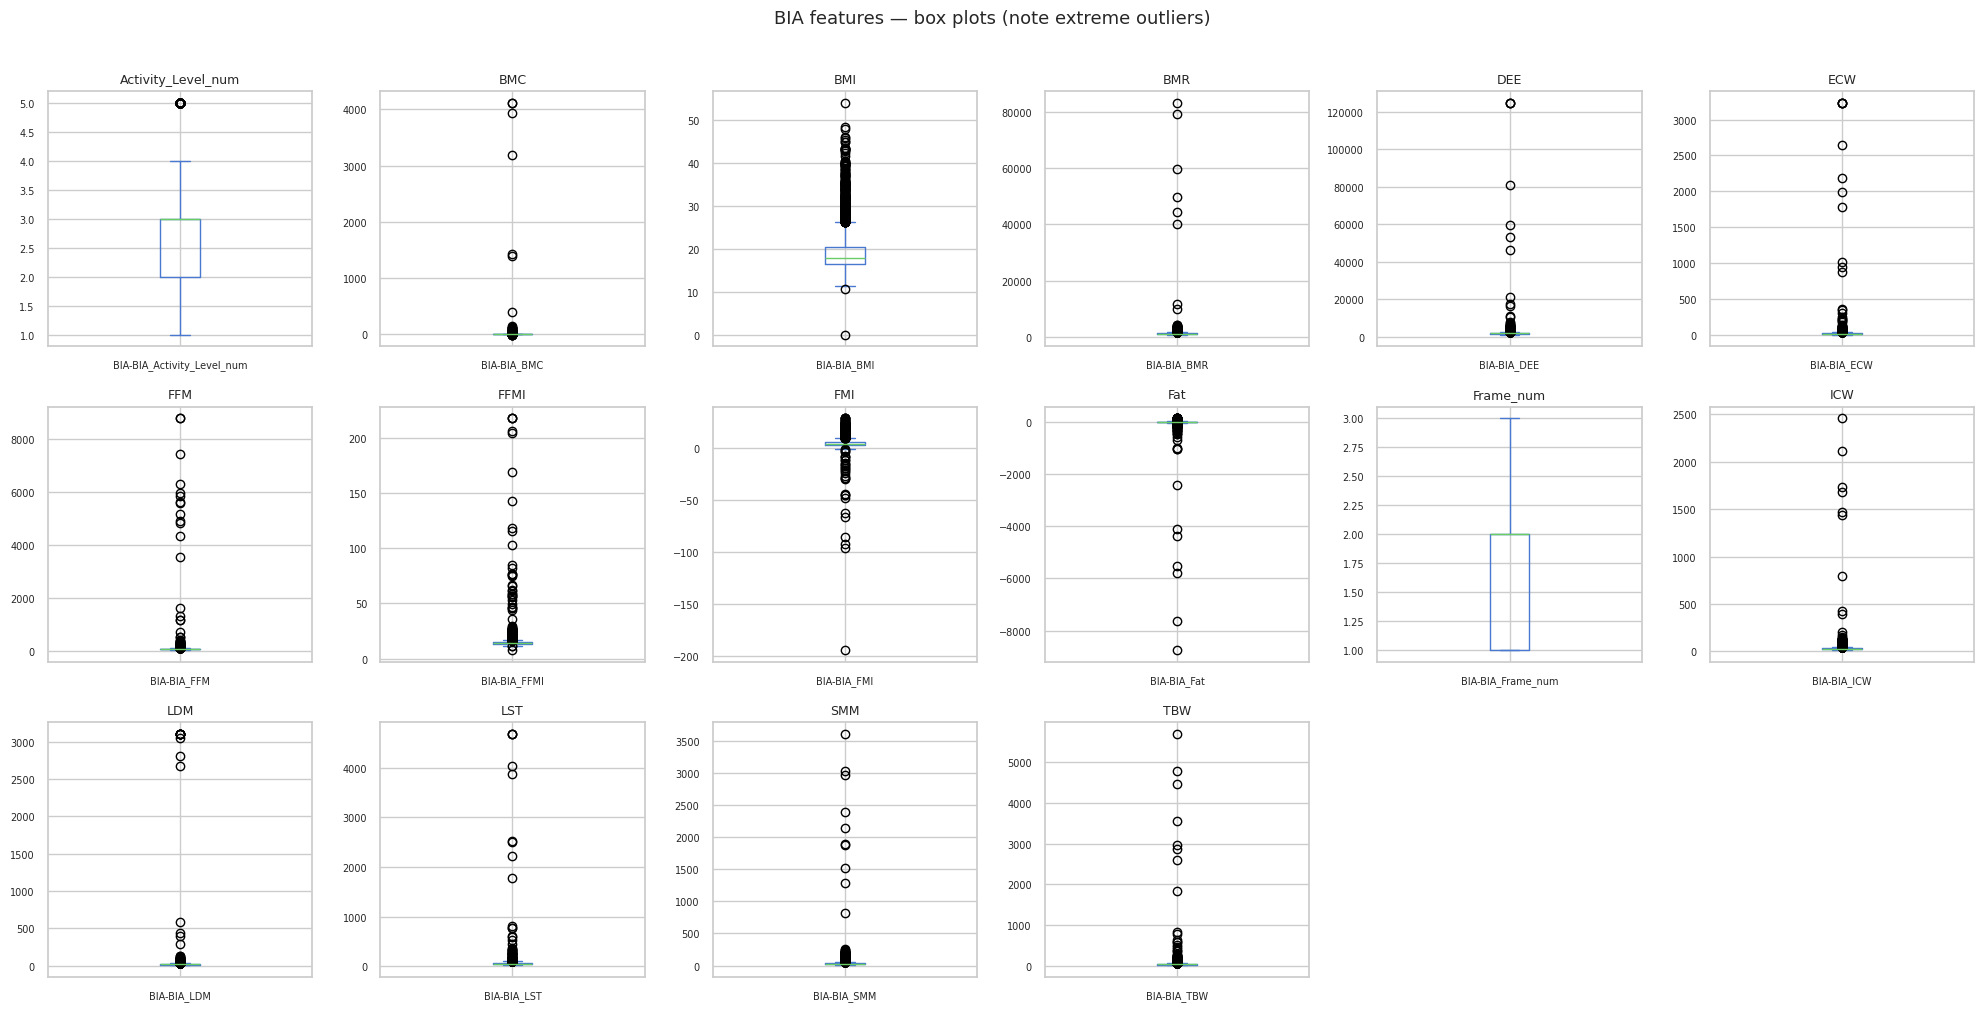

In [6]:
# Box plots to spot outliers
bia_cols = [c for c in df.columns if c.startswith("BIA-") and "Season" not in c]
fig, axes = plt.subplots(3, 6, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(bia_cols):
    df[col].dropna().plot.box(ax=axes[i], vert=True)
    axes[i].set_title(col.replace("BIA-BIA_", ""), fontsize=9)
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("BIA features — box plots (note extreme outliers)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Observations — BIA outliers:**

The box plots confirm that several BIA variables have extreme outliers far beyond the whiskers (e.g. BMR up to ~83,000 vs a median ~1,200; FFM up to ~8,800 vs a median ~30). These are almost certainly recording errors and will need to be addressed during cleaning.

---
## Step 3. Linear Correlation

Now we look at how features relate to each other and to the target `sii`.

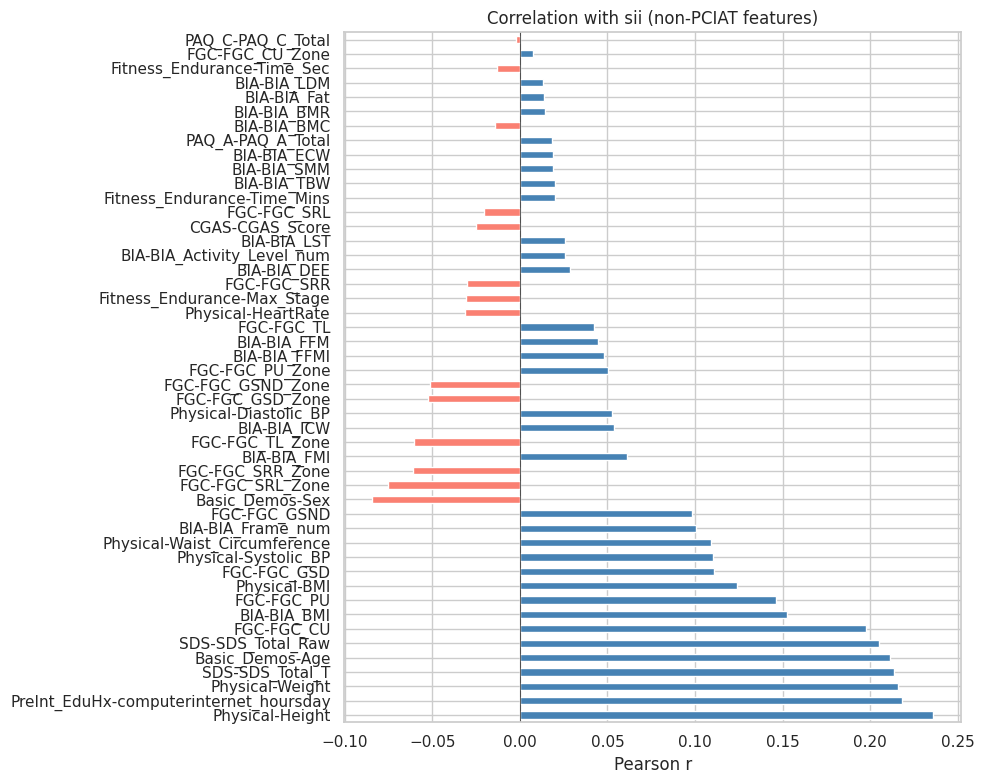

Top 10 absolute correlates:
Physical-Height                           0.235959
PreInt_EduHx-computerinternet_hoursday    0.217851
Physical-Weight                           0.215526
SDS-SDS_Total_T                           0.213574
Basic_Demos-Age                           0.211182
SDS-SDS_Total_Raw                         0.204893
FGC-FGC_CU                                0.197678
BIA-BIA_BMI                               0.152289
FGC-FGC_PU                                0.146300
Physical-BMI                              0.123990


In [7]:
# Correlation with sii — only non-PCIAT, non-Season features
numeric = df.select_dtypes("number").drop(columns=["id"])
pciat_cols = [c for c in numeric.columns if "PCIAT" in c]
corr_sii = (numeric.drop(columns=pciat_cols)
            .corrwith(numeric["sii"])
            .drop("sii")
            .sort_values(key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(10, 8))
corr_sii.plot.barh(ax=ax, color=corr_sii.apply(lambda x: "steelblue" if x >= 0 else "salmon"))
ax.set_title("Correlation with sii (non-PCIAT features)")
ax.set_xlabel("Pearson r")
ax.axvline(0, color="k", lw=0.5)
plt.tight_layout()
plt.show()

print("Top 10 absolute correlates:")
print(corr_sii.head(10).to_string())

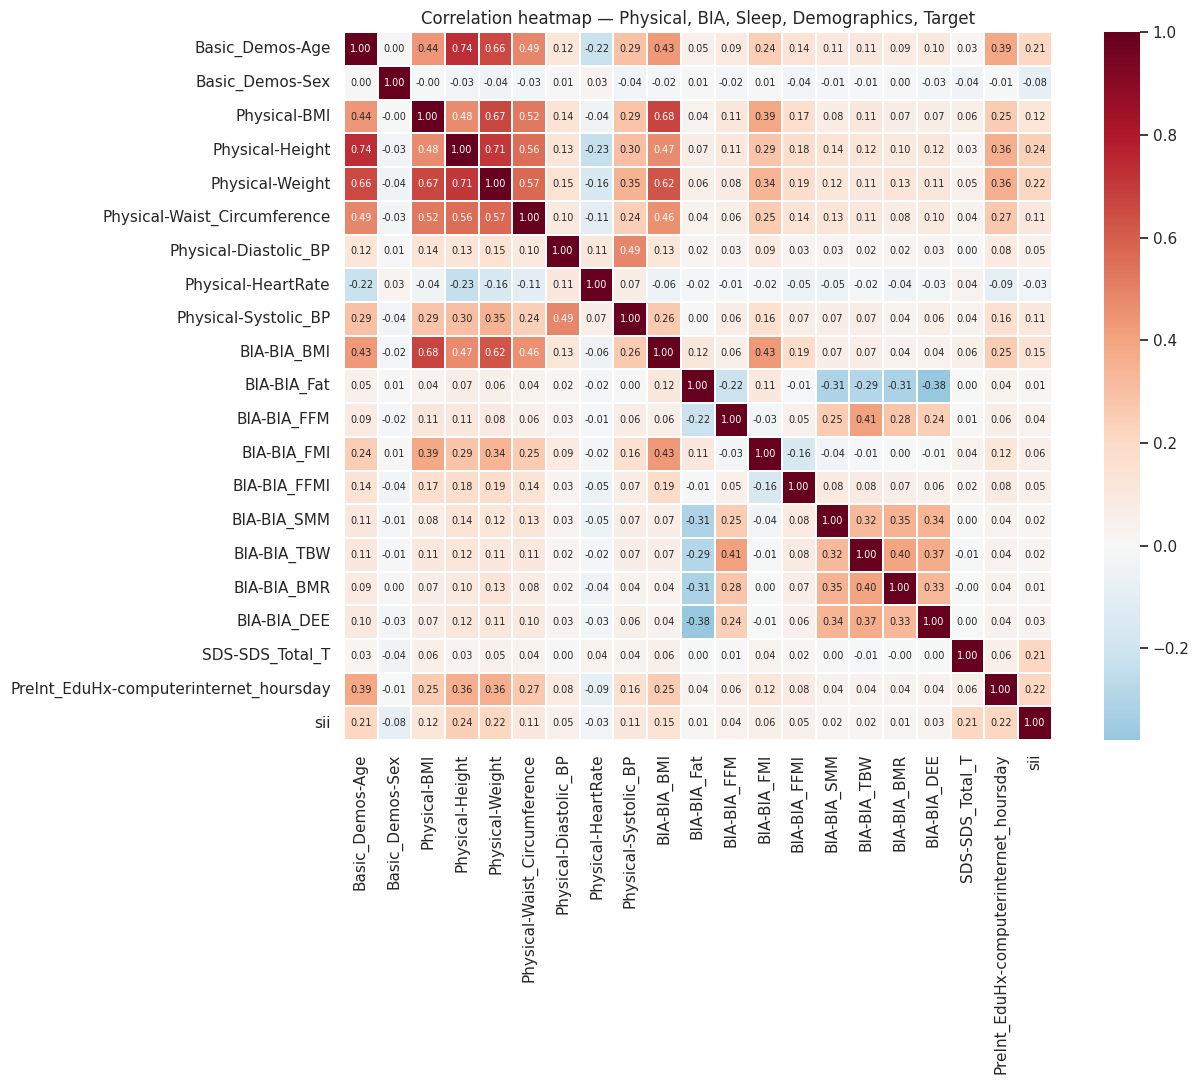

In [8]:
# Correlation heatmap among feature groups (Physical + BIA + FGC + Demographics)
keep_for_heatmap = [
    "Basic_Demos-Age", "Basic_Demos-Sex",
    "Physical-BMI", "Physical-Height", "Physical-Weight",
    "Physical-Waist_Circumference", "Physical-Diastolic_BP",
    "Physical-HeartRate", "Physical-Systolic_BP",
    "BIA-BIA_BMI", "BIA-BIA_Fat", "BIA-BIA_FFM", "BIA-BIA_FMI",
    "BIA-BIA_FFMI", "BIA-BIA_SMM", "BIA-BIA_TBW", "BIA-BIA_BMR",
    "BIA-BIA_DEE",
    "SDS-SDS_Total_T", "PreInt_EduHx-computerinternet_hoursday",
    "sii",
]

corr_mat = df[keep_for_heatmap].corr()
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.3, ax=ax, annot_kws={"size": 7})
ax.set_title("Correlation heatmap — Physical, BIA, Sleep, Demographics, Target")
plt.tight_layout()
plt.show()

Observations — correlations:
- The strongest non-PCIAT correlates with `sii` are modest: Height (0.24), Internet hours/day (0.22), Weight (0.22), Sleep T-score (0.21), Age (0.21).
- BIA and Physical features are highly correlated with each other (e.g. FFM ↔ TBW ↔ SMM ↔ LST, Physical-BMI ↔ BIA-BMI). This multicollinearity should be kept in mind during modelling.
- Sleep disturbance (SDS_Total_T) positively correlates with `sii`, more sleep problems associate with more internet use problems.

---
## Step 4. Target Variable Analysis

Having explored the features, we now examine the target variable `sii` (Severity Impairment Index) and its relationship with the PCIAT instrument.

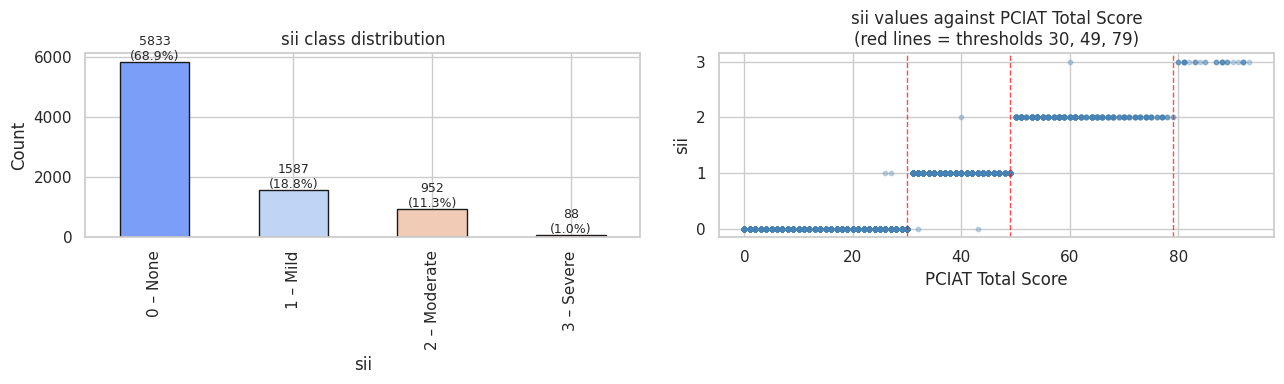

In [9]:
sii_labels = {0: "None", 1: "Mild", 2: "Moderate", 3: "Severe"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Class distribution
counts = df["sii"].value_counts().sort_index()
counts.index = counts.index.map(lambda x: f"{int(x)} – {sii_labels[int(x)]}")
counts.plot.bar(ax=axes[0], color=sns.color_palette("coolwarm", 4), edgecolor="k")
axes[0].set_title("sii class distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts):
    axes[0].text(i, v + 50, f"{v}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=9)

# sii vs PCIAT_Total — show derivation
mask = df["PCIAT-PCIAT_Total"].notna()
axes[1].scatter(df.loc[mask, "PCIAT-PCIAT_Total"], df.loc[mask, "sii"],
                alpha=0.3, s=10, c="steelblue")
for thr in [30, 49, 79]:
    axes[1].axvline(thr, color="red", ls="--", lw=1, alpha=0.7)
axes[1].set_xlabel("PCIAT Total Score")
axes[1].set_ylabel("sii")
axes[1].set_title("sii values against PCIAT Total Score\n(red lines = thresholds 30, 49, 79)")

plt.tight_layout()
plt.show()

Key finding: `sii` is derived directly from `PCIAT_Total`.

The scatter plot reveals a deterministic step-function relationship. According to the data dictionary, `sii` is the Severity Impairment Index computed by binning `PCIAT_Total` with thresholds from the official PCIAT scoring guide:

| PCIAT Total | sii | Label |
|---|---|---|
| 0–30 | 0 | None |
| 31–49 | 1 | Mild |
| 50–79 | 2 | Moderate |
| 80–100 | 3 | Severe |

Implication for modelling: All 22 PCIAT columns (20 items + Total + Season) must be dropped from the feature set. Using them would constitute data leakage.

Target imbalance: The target is heavily skewed — 68.9% of participants fall in class 0 (None) and only 1.0% in class 3 (Severe). This will need to be addressed during modelling (e.g. class weights, oversampling).

---
## Step 5. Data Cleaning

Based on the previous observations, we now address: erroneous values, column drops (PCIAT leakage, Season low-signal), and extreme BIA outliers.

In [10]:
# --- 5a. Drop columns: id, all PCIAT, all Season columns ---
season_cols = [c for c in df.columns if "Season" in c]
pciat_cols_all = [c for c in df.columns if "PCIAT" in c]

print(f"Dropping {len(season_cols)} Season columns: {season_cols}")
print(f"Dropping {len(pciat_cols_all)} PCIAT columns")
print("Dropping: id")

df_clean = df.drop(columns=["id"] + season_cols + pciat_cols_all)
print(f"\nShape after drops: {df_clean.shape}")

Dropping 11 Season columns: ['Basic_Demos-Enroll_Season', 'CGAS-Season', 'Physical-Season', 'Fitness_Endurance-Season', 'FGC-Season', 'BIA-Season', 'PAQ_A-Season', 'PAQ_C-Season', 'PCIAT-Season', 'SDS-Season', 'PreInt_EduHx-Season']
Dropping 22 PCIAT columns
Dropping: id

Shape after drops: (8460, 49)


In [11]:
# --- 5b. Fix erroneous / impossible values → NaN ---

fixes = {}

# CGAS = 999 (scale is 1–100)
mask = df_clean["CGAS-CGAS_Score"] == 999
fixes["CGAS-CGAS_Score == 999"] = mask.sum()
df_clean.loc[mask, "CGAS-CGAS_Score"] = np.nan

# Physical-BMI = 0
mask = df_clean["Physical-BMI"] <= 0
fixes["Physical-BMI == 0"] = mask.sum()
df_clean.loc[mask, "Physical-BMI"] = np.nan

# Physical-Weight = 0
mask = df_clean["Physical-Weight"] <= 0
fixes["Physical-Weight == 0"] = mask.sum()
df_clean.loc[mask, "Physical-Weight"] = np.nan

# Diastolic_BP = 0
mask = df_clean["Physical-Diastolic_BP"] <= 0
fixes["Physical-Diastolic_BP == 0"] = mask.sum()
df_clean.loc[mask, "Physical-Diastolic_BP"] = np.nan

# Systolic_BP = 0
mask = df_clean["Physical-Systolic_BP"] <= 0
fixes["Physical-Systolic_BP == 0"] = mask.sum()
df_clean.loc[mask, "Physical-Systolic_BP"] = np.nan

# BIA-BIA_Fat < 0 (negative body fat impossible)
mask = df_clean["BIA-BIA_Fat"] <= 0
fixes["BIA-BIA_Fat < 0"] = mask.sum()
df_clean.loc[mask, "BIA-BIA_Fat"] = np.nan

# BIA-BIA_FMI < 0
mask = df_clean["BIA-BIA_FMI"] <= 0
fixes["BIA-BIA_FMI < 0"] = mask.sum()
df_clean.loc[mask, "BIA-BIA_FMI"] = np.nan

# BIA-BIA_ECW < 0 (negative extracellular water is biologically impossible)
mask = df_clean["BIA-BIA_ECW"] <= 0
fixes["BIA-BIA_ECW < 0"] = mask.sum()
df_clean.loc[mask, "BIA-BIA_ECW"] = np.nan

# BIA-BIA_ICW < 0 (negative intracellular water is biologically impossible)
mask = df_clean["BIA-BIA_ICW"] <= 0
fixes["BIA-BIA_ICW < 0"] = mask.sum()
df_clean.loc[mask, "BIA-BIA_ICW"] = np.nan

# BIA-BIA_BMC < 0 (negative bone mineral content is biologically impossible)
mask = df_clean["BIA-BIA_BMC"] <= 0
fixes["BIA-BIA_BMC < 0"] = mask.sum()
df_clean.loc[mask, "BIA-BIA_BMC"] = np.nan

print("Erroneous values replaced with NaN:")
for k, v in fixes.items():
    print(f"  {k}: {v} rows")

Erroneous values replaced with NaN:
  CGAS-CGAS_Score == 999: 4 rows
  Physical-BMI == 0: 7 rows
  Physical-Weight == 0: 81 rows
  Physical-Diastolic_BP == 0: 1 rows
  Physical-Systolic_BP == 0: 1 rows
  BIA-BIA_Fat < 0: 112 rows
  BIA-BIA_FMI < 0: 51 rows
  BIA-BIA_ECW < 0: 0 rows
  BIA-BIA_ICW < 0: 0 rows
  BIA-BIA_BMC < 0: 34 rows


In [12]:
# --- 5c. Handle BIA outliers ---
# BIA features have extreme values that are clearly measurement/recording errors
# (e.g. BMR = 83,000 vs median ~1,200; FFM = 8,800 vs median ~30).
#
# Strategy:
#   1. REMOVE rows with truly extreme BIA values (beyond 10×IQR) — these are
#      impossible measurements, not real biological variation.
#   2. CAP remaining moderate outliers at the 1st/99th percentile (winsorization)
#      to reduce their influence without losing data.

bia_continuous = [c for c in df_clean.columns
                  if c.startswith("BIA-") and c not in
                  ["BIA-BIA_Activity_Level_num", "BIA-BIA_Frame_num"]]

# Step 1: identify rows with extreme BIA values (10×IQR)
extreme_mask = pd.Series(False, index=df_clean.index)
for col in bia_continuous:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 10 * iqr
    upper = q3 + 10 * iqr
    extreme_mask |= df_clean[col].notna() & ((df_clean[col] < lower) | (df_clean[col] > upper))

n_extreme = extreme_mask.sum()
print(f"Rows with extreme BIA outliers (10×IQR): {n_extreme} ({n_extreme/len(df_clean)*100:.2f}%)")
df_clean = df_clean[~extreme_mask].reset_index(drop=True)
print(f"Shape after removal: {df_clean.shape}")

# Step 2: cap remaining moderate outliers at 1st/99th percentile
capped = {}
for col in bia_continuous:
    p01 = df_clean[col].quantile(0.01)
    p99 = df_clean[col].quantile(0.99)
    below = (df_clean[col] < p01).sum()
    above = (df_clean[col] > p99).sum()
    if below + above > 0:
        capped[col] = {"below": below, "above": above,
                       "bounds": f"[{p01:.1f}, {p99:.1f}]"}
        df_clean[col] = df_clean[col].clip(lower=p01, upper=p99)

print(f"\nWinsorized {len(capped)} BIA columns at 1st/99th percentile:")
for k, v in capped.items():
    print(f"  {k}: {v['below']} below + {v['above']} above → clipped to {v['bounds']}")

Rows with extreme BIA outliers (10×IQR): 217 (2.57%)
Shape after removal: (8243, 49)

Winsorized 14 BIA columns at 1st/99th percentile:
  BIA-BIA_BMC: 65 below + 65 above → clipped to [1.7, 9.9]
  BIA-BIA_BMI: 65 below + 65 above → clipped to [13.9, 34.5]
  BIA-BIA_BMR: 65 below + 65 above → clipped to [877.1, 1889.3]
  BIA-BIA_DEE: 65 below + 65 above → clipped to [1171.5, 3452.7]
  BIA-BIA_ECW: 65 below + 65 above → clipped to [5.2, 46.8]
  BIA-BIA_FFM: 65 below + 65 above → clipped to [33.5, 142.0]
  BIA-BIA_FFMI: 65 below + 65 above → clipped to [12.7, 21.3]
  BIA-BIA_FMI: 65 below + 65 above → clipped to [0.8, 17.8]
  BIA-BIA_Fat: 64 below + 64 above → clipped to [1.8, 92.6]
  BIA-BIA_ICW: 65 below + 65 above → clipped to [17.6, 58.5]
  BIA-BIA_LDM: 65 below + 65 above → clipped to [8.8, 41.0]
  BIA-BIA_LST: 65 below + 65 above → clipped to [31.7, 131.6]
  BIA-BIA_SMM: 65 below + 65 above → clipped to [14.3, 77.2]
  BIA-BIA_TBW: 65 below + 65 above → clipped to [21.0, 98.4]


---
## Step 6. Encoding Categorical Variables

All categoricals are already numerically encoded:
- `Basic_Demos-Sex` (0/1) — binary, keep as-is
- `FGC-*_Zone` (0/1) — binary, keep as-is  
- `FGC-FGC_GSND_Zone`, `FGC-FGC_GSD_Zone` (1/2/3) — ordinal (Weak < Normal < Strong), keep numeric
- `BIA-BIA_Activity_Level_num` (1–5) — ordinal, keep numeric
- `BIA-BIA_Frame_num` (1/2/3) — ordinal, keep numeric
- `PreInt_EduHx-computerinternet_hoursday` (0–3) — ordinal, keep numeric

No encoding transformations needed, all variables are already in a suitable numeric format.

---
## Step 7. Feature Engineering

`PAQ_A-PAQ_A_Total` refers to Activity Summary Score for adolescents, meanwhile `PAQ_C-PAQ_C_Total` refers to children.

These metrics are almost always mutually exclusive, therefore they are merged into one.

When both are present, the average is used.

In [13]:
paq_a = df_clean["PAQ_A-PAQ_A_Total"]
paq_c = df_clean["PAQ_C-PAQ_C_Total"]

df_clean["PAQ_Combined"] = np.where(
    paq_a.notna() & paq_c.notna(), (paq_a + paq_c) / 2,
    np.where(paq_a.notna(), paq_a, paq_c)
)

# Drop originals
df_clean = df_clean.drop(columns=["PAQ_A-PAQ_A_Total", "PAQ_C-PAQ_C_Total",
                                   "PAQ_A-Season", "PAQ_C-Season"], errors="ignore")

print(f"PAQ_Combined — non-null: {df_clean['PAQ_Combined'].notna().sum()}, "
      f"null: {df_clean['PAQ_Combined'].isna().sum()}")
df_clean["PAQ_Combined"].describe()

PAQ_Combined — non-null: 7495, null: 748


count    7495.000000
mean        2.386186
std         0.539055
min         0.580000
25%         2.000000
50%         2.435000
75%         2.560000
max         5.000000
Name: PAQ_Combined, dtype: float64

`Fitness_Endurance_TotalTime` is calculated as the total number of seconds, using `Mins` and `Sec`.

In [14]:
mins = df_clean["Fitness_Endurance-Time_Mins"]
secs = df_clean["Fitness_Endurance-Time_Sec"]
either_present = mins.notna() | secs.notna()

df_clean["Fitness_Endurance_TotalTime"] = np.where(
    either_present,
    mins.fillna(0) * 60 + secs.fillna(0),
    np.nan
)

# Drop the two original time columns (keep Max_Stage)
df_clean = df_clean.drop(columns=["Fitness_Endurance-Time_Mins",
                                   "Fitness_Endurance-Time_Sec"])

non_null = df_clean["Fitness_Endurance_TotalTime"].notna().sum()
null = df_clean["Fitness_Endurance_TotalTime"].isna().sum()
print(f"Fitness_Endurance_TotalTime — non-null: {non_null}, null: {null} ({null/len(df_clean)*100:.1f}%)")
df_clean["Fitness_Endurance_TotalTime"].describe()

Fitness_Endurance_TotalTime — non-null: 7046, null: 1197 (14.5%)


count    7046.000000
mean      338.931025
std       199.209348
min         0.000000
25%        54.500000
50%       420.000000
75%       468.000000
max      1200.000000
Name: Fitness_Endurance_TotalTime, dtype: float64

---
## Step 8. Unit Conversion (Imperial → Metric)

The Physical measures use imperial units. We convert them to metric for easier interpretation:
- Height: inches → centimetres (× 2.54)
- Weight: pounds → kilograms (× 0.4536)
- Waist Circumference: inches → centimetres (× 2.54)

BMI is already in kg/m² (universal) — no conversion needed.

In [15]:
# Convert imperial → metric
df_clean["Physical-Height"] = df_clean["Physical-Height"] * 2.54          # in → cm
df_clean["Physical-Weight"] = df_clean["Physical-Weight"] * 0.453592      # lbs → kg
df_clean["Physical-Waist_Circumference"] = df_clean["Physical-Waist_Circumference"] * 2.54  # in → cm

print("Converted to metric:")
print(f"  Height: {df_clean['Physical-Height'].describe()[['mean','min','max']].to_string()}")
print(f"  Weight: {df_clean['Physical-Weight'].describe()[['mean','min','max']].to_string()}")
print(f"  Waist:  {df_clean['Physical-Waist_Circumference'].describe()[['mean','min','max']].to_string()}")

Converted to metric:
  Height: mean    144.872753
min      83.820000
max     199.390000
  Weight: mean     38.442618
min       0.317514
max     142.881480
  Waist:  mean     68.308504
min      45.720000
max     127.000000


---
## Step 9. Variable Selection (before imputation)

We remove redundant and low-signal variables **before** imputation so that MICE
operates on a cleaner, lower-dimensional feature set.

Selection criteria (all computed on the cleaned, pre-imputation data):

### A. Multicollinear BIA lean-mass cluster

Eight BIA variables form a single highly correlated block (all pairwise |r| > 0.80):
`FFM`, `LST`, `BMR`, `TBW`, `ECW`, `ICW`, `SMM`, `LDM`, `DEE`.

They all measure overlapping aspects of lean body mass / body water / metabolism.
We keep **`BIA_FFM`** (highest sii correlation in the cluster, r = 0.241) and drop the rest.

| Drop | r with FFM | r with sii | Why redundant |
|---|---|---|---|
| `BIA_LST` | 0.907 | 0.241 | FFM ≈ LST + BMC |
| `BIA_BMR` | 0.916 | 0.225 | Metabolic derivative of lean mass |
| `BIA_TBW` | 0.883 | 0.227 | Water component = ECW + ICW |
| `BIA_ECW` | 0.859 | 0.206 | Subset of TBW |
| `BIA_ICW` | 0.848 | 0.235 | Subset of TBW |
| `BIA_SMM` | 0.838 | 0.218 | Skeletal subset of FFM |
| `BIA_DEE` | via BMR | 0.217 | DEE = BMR × activity multiplier |
| `BIA_LDM` | via BMR 0.823 | 0.200 | Dry component of lean mass |

### B. Duplicate metrics

| Drop | Keep | Reason |
|---|---|---|
| `BIA_BMI` (r=0.159) | `Physical-BMI` (r=0.126) | Same metric from different instrument |
| `SDS_Total_Raw` (r=0.196) | `SDS_Total_T` (r=0.210) | T-score is the standardized form (r=0.808 between them) |

### C. FGC: keep whichever of raw / zone has higher sii signal

| Test | Keep | r | Drop | r | Reason |
|---|---|---|---|---|---|
| Curl-Up | raw `FGC_CU` | 0.200 | `FGC_CU_Zone` | 0.005 | Zone near-zero signal |
| Push-Up | raw `FGC_PU` | 0.148 | `FGC_PU_Zone` | 0.049 | Raw 3× stronger |
| Grip ND | raw `FGC_GSND` | 0.100 | `FGC_GSND_Zone` | 0.049 | Zone 84% one class |
| Grip D | raw `FGC_GSD` | 0.111 | `FGC_GSD_Zone` | 0.052 | Zone 85% one class |
| Sit&Reach L | zone `FGC_SRL_Zone` | 0.076 | `FGC_SRL` | 0.018 | Zone 4× stronger |
| Sit&Reach R | zone `FGC_SRR_Zone` | 0.060 | `FGC_SRR` | 0.029 | Zone 2× stronger |
| Trunk Lift | zone `FGC_TL_Zone` | 0.055 | `FGC_TL` | 0.044 | Marginal; zone slightly better |

### D. Near-zero signal (|r| < 0.03 with sii)

| Drop | r with sii | Reason |
|---|---|---|
| `Fitness_Endurance_TotalTime` | 0.003 | Engineered variable, no signal |
| `PAQ_Combined` | 0.008 | Engineered variable, no signal |
| `BIA_Activity_Level_num` | 0.028 | 56% in one class, negligible signal |

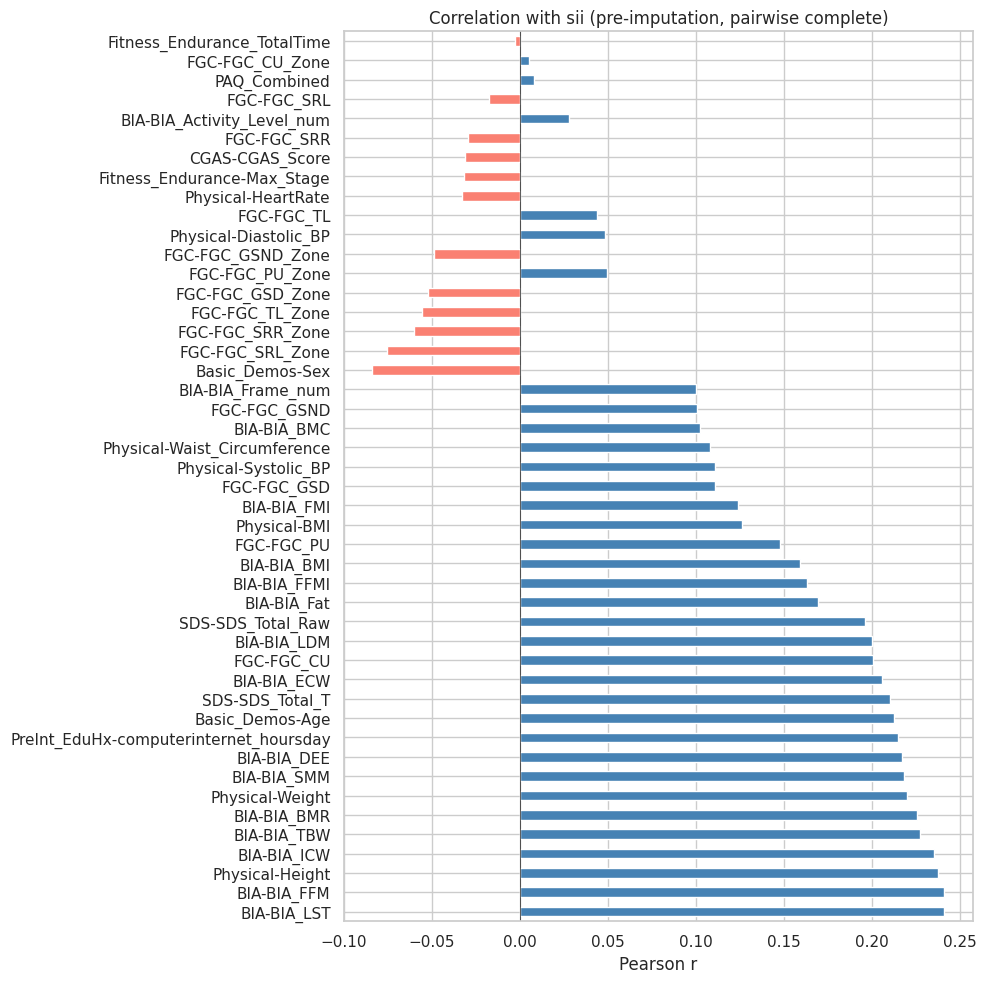

Top 15 absolute correlates with sii:
BIA-BIA_LST                               0.241
BIA-BIA_FFM                               0.241
Physical-Height                           0.238
BIA-BIA_ICW                               0.235
BIA-BIA_TBW                               0.227
BIA-BIA_BMR                               0.225
Physical-Weight                           0.220
BIA-BIA_SMM                               0.218
BIA-BIA_DEE                               0.217
PreInt_EduHx-computerinternet_hoursday    0.215
Basic_Demos-Age                           0.212
SDS-SDS_Total_T                           0.210
BIA-BIA_ECW                               0.206
FGC-FGC_CU                                0.200
BIA-BIA_LDM                               0.200


In [16]:
# --- 9a. Correlation analysis (pre-imputation, pairwise complete obs) ---
numeric_pre = df_clean.select_dtypes("number")
corr_sii_pre = (numeric_pre.corrwith(numeric_pre["sii"])
                .drop("sii")
                .sort_values(key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(10, 10))
corr_sii_pre.plot.barh(ax=ax,
    color=corr_sii_pre.apply(lambda x: "steelblue" if x >= 0 else "salmon"))
ax.set_title("Correlation with sii (pre-imputation, pairwise complete)")
ax.set_xlabel("Pearson r")
ax.axvline(0, color="k", lw=0.5)
plt.tight_layout()
plt.show()

print("Top 15 absolute correlates with sii:")
print(corr_sii_pre.head(15).round(3).to_string())

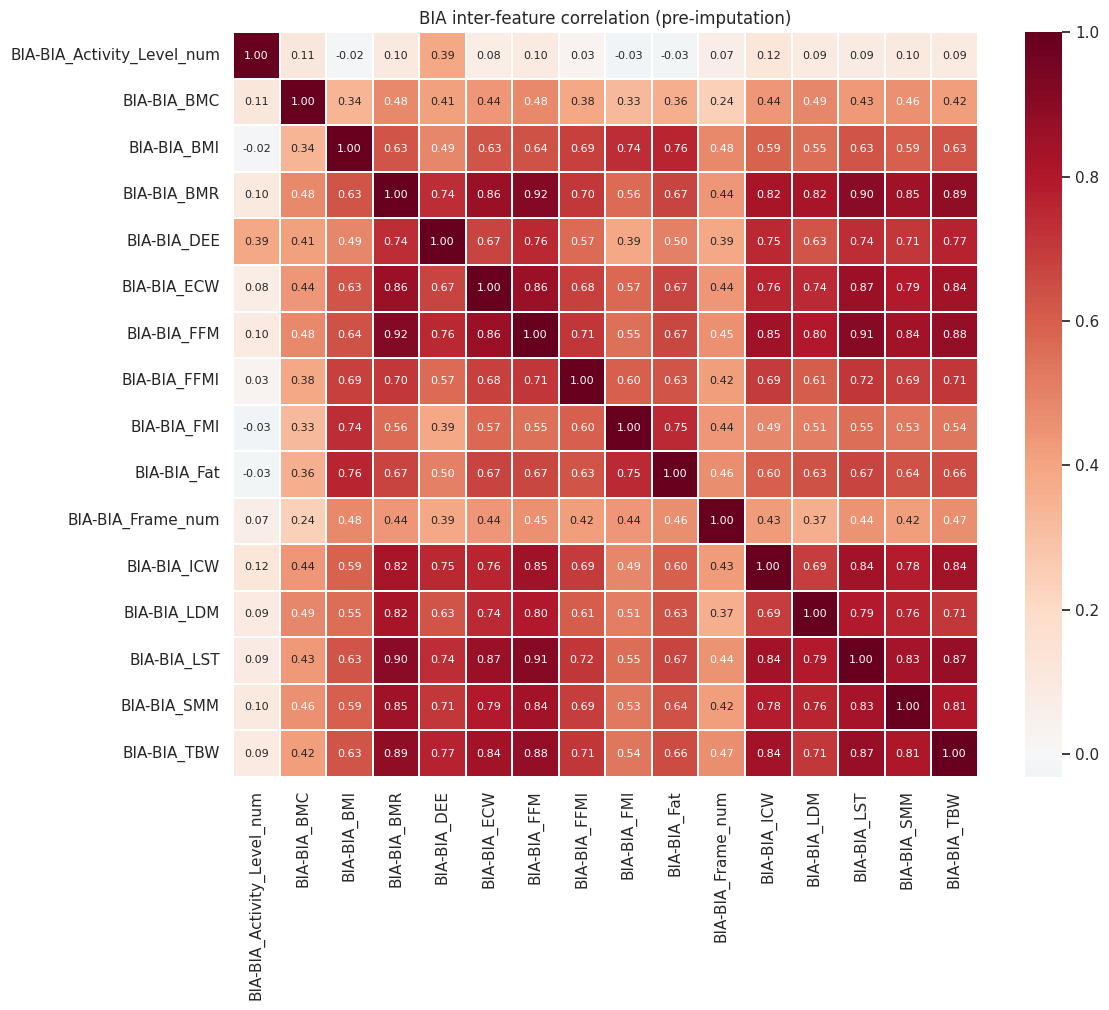

Feature pairs with |r| > 0.80:
  +0.860  BIA-BIA_BMR  <->  BIA-BIA_ECW
  +0.916  BIA-BIA_BMR  <->  BIA-BIA_FFM
  +0.819  BIA-BIA_BMR  <->  BIA-BIA_ICW
  +0.823  BIA-BIA_BMR  <->  BIA-BIA_LDM
  +0.900  BIA-BIA_BMR  <->  BIA-BIA_LST
  +0.849  BIA-BIA_BMR  <->  BIA-BIA_SMM
  +0.886  BIA-BIA_BMR  <->  BIA-BIA_TBW
  +0.859  BIA-BIA_ECW  <->  BIA-BIA_FFM
  +0.866  BIA-BIA_ECW  <->  BIA-BIA_LST
  +0.843  BIA-BIA_ECW  <->  BIA-BIA_TBW
  +0.848  BIA-BIA_FFM  <->  BIA-BIA_ICW
  +0.907  BIA-BIA_FFM  <->  BIA-BIA_LST
  +0.838  BIA-BIA_FFM  <->  BIA-BIA_SMM
  +0.883  BIA-BIA_FFM  <->  BIA-BIA_TBW
  +0.839  BIA-BIA_ICW  <->  BIA-BIA_LST
  +0.838  BIA-BIA_ICW  <->  BIA-BIA_TBW
  +0.830  BIA-BIA_LST  <->  BIA-BIA_SMM
  +0.873  BIA-BIA_LST  <->  BIA-BIA_TBW
  +0.807  BIA-BIA_SMM  <->  BIA-BIA_TBW


In [17]:
# --- 9b. Inter-feature correlation heatmap (BIA block) ---
bia_cols_check = [c for c in df_clean.columns if c.startswith("BIA-") and "Season" not in c]
corr_bia = df_clean[bia_cols_check].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_bia, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.3, ax=ax, annot_kws={"size": 8})
ax.set_title("BIA inter-feature correlation (pre-imputation)")
plt.tight_layout()
plt.show()

# Print pairs with |r| > 0.80
print("Feature pairs with |r| > 0.80:")
for i in range(len(corr_bia.columns)):
    for j in range(i+1, len(corr_bia.columns)):
        r = corr_bia.iloc[i, j]
        if abs(r) > 0.80:
            print(f"  {r:+.3f}  {corr_bia.columns[i]}  <->  {corr_bia.columns[j]}")

In [18]:
# --- 9c. Drop redundant / low-signal variables ---

# A. Multicollinear BIA lean-mass cluster (keep FFM only)
bia_drop = [
    "BIA-BIA_LST",   # r=0.907 with FFM
    "BIA-BIA_BMR",   # r=0.916 with FFM
    "BIA-BIA_TBW",   # r=0.883 with FFM (= ECW + ICW)
    "BIA-BIA_ECW",   # r=0.859 with FFM
    "BIA-BIA_ICW",   # r=0.848 with FFM
    "BIA-BIA_SMM",   # r=0.838 with FFM
    "BIA-BIA_DEE",   # derived from BMR
    "BIA-BIA_LDM",   # r=0.823 with BMR
]

# B. Duplicate metrics
dup_drop = [
    "BIA-BIA_BMI",       # same as Physical-BMI
    "SDS-SDS_Total_Raw", # T-score is the standardized form
]

# C. FGC: drop whichever of raw/zone has lower sii signal
fgc_drop = [
    "FGC-FGC_CU_Zone",   # |r|=0.005 vs raw 0.200
    "FGC-FGC_PU_Zone",   # |r|=0.049 vs raw 0.148
    "FGC-FGC_GSND_Zone", # |r|=0.049 vs raw 0.100, 84% one class
    "FGC-FGC_GSD_Zone",  # |r|=0.052 vs raw 0.111, 85% one class
    "FGC-FGC_SRL",       # |r|=0.018 vs zone 0.076
    "FGC-FGC_SRR",       # |r|=0.029 vs zone 0.060
    "FGC-FGC_TL",        # |r|=0.044 vs zone 0.055
]

# D. Near-zero signal
zero_drop = [
    "Fitness_Endurance_TotalTime",       # |r|=0.003
    "PAQ_Combined",                       # |r|=0.008
    "BIA-BIA_Activity_Level_num",         # |r|=0.028, 56% one class
]

all_drop = bia_drop + dup_drop + fgc_drop + zero_drop
print(f"Dropping {len(all_drop)} variables:")
for group, cols in [("BIA cluster", bia_drop), ("Duplicates", dup_drop),
                     ("FGC raw/zone", fgc_drop), ("Near-zero signal", zero_drop)]:
    print(f"\n  {group} ({len(cols)}):")
    for c in cols:
        print(f"    - {c}")

df_clean = df_clean.drop(columns=all_drop)
print(f"\nShape after variable selection: {df_clean.shape}")
print(f"Remaining features: {[c for c in df_clean.columns if c != 'sii']}")

Dropping 20 variables:

  BIA cluster (8):
    - BIA-BIA_LST
    - BIA-BIA_BMR
    - BIA-BIA_TBW
    - BIA-BIA_ECW
    - BIA-BIA_ICW
    - BIA-BIA_SMM
    - BIA-BIA_DEE
    - BIA-BIA_LDM

  Duplicates (2):
    - BIA-BIA_BMI
    - SDS-SDS_Total_Raw

  FGC raw/zone (7):
    - FGC-FGC_CU_Zone
    - FGC-FGC_PU_Zone
    - FGC-FGC_GSND_Zone
    - FGC-FGC_GSD_Zone
    - FGC-FGC_SRL
    - FGC-FGC_SRR
    - FGC-FGC_TL

  Near-zero signal (3):
    - Fitness_Endurance_TotalTime
    - PAQ_Combined
    - BIA-BIA_Activity_Level_num

Shape after variable selection: (8243, 27)
Remaining features: ['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-BMI', 'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference', 'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP', 'Fitness_Endurance-Max_Stage', 'FGC-FGC_CU', 'FGC-FGC_GSND', 'FGC-FGC_GSD', 'FGC-FGC_PU', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR_Zone', 'FGC-FGC_TL_Zone', 'BIA-BIA_BMC', 'BIA-BIA_FFM', 'BIA-BIA_FFMI', 'B

---
## Step 10. Deterministic Imputation

Before statistical imputation, we compute missing values from known physical formulas where 2 of 3 variables are present:

- BMI = Weight_kg / (Height_m)²  — recover any one from the other two

In [19]:
def deterministic_impute(df):
    """Fill missing values using known physical formulas.
    Only fills where exactly 1 of the group is missing and the others are present."""
    filled = {}

    # --- BMI / Height / Weight (metric: BMI = kg / m²) ---
    h = df["Physical-Height"]       # cm
    w = df["Physical-Weight"]       # kg
    b = df["Physical-BMI"]          # kg/m²
    h_m = h / 100                   # cm → m

    # BMI missing, H + W present
    mask = b.isna() & h.notna() & w.notna() & (h_m > 0)
    filled["Physical-BMI"] = mask.sum()
    df.loc[mask, "Physical-BMI"] = w[mask] / (h_m[mask] ** 2)

    # Weight missing, H + BMI present
    mask = w.isna() & h.notna() & b.notna() & (h_m > 0)
    filled["Physical-Weight"] = mask.sum()
    df.loc[mask, "Physical-Weight"] = b[mask] * (h_m[mask] ** 2)

    # Height missing, W + BMI present
    mask = h.isna() & w.notna() & b.notna() & (b > 0)
    filled["Physical-Height"] = mask.sum()
    df.loc[mask, "Physical-Height"] = np.sqrt(w[mask] / b[mask]) * 100  # m → cm

    return filled

filled = deterministic_impute(df_clean)
total = sum(filled.values())
print(f"Deterministic imputation — {total} values recovered:")
for col, n in filled.items():
    if n > 0:
        print(f"  {col}: {n} values computed from formula")

Deterministic imputation — 1294 values recovered:
  Physical-BMI: 427 values computed from formula
  Physical-Weight: 442 values computed from formula
  Physical-Height: 425 values computed from formula


In [20]:
# Updated missing-value summary after deterministic imputation
print(f"Shape: {df_clean.shape}")
print()

miss_final = df_clean.isnull().sum()
miss_final_pct = (miss_final / len(df_clean) * 100).round(1)
summary = (pd.DataFrame({"missing": miss_final, "pct%": miss_final_pct})
           .sort_values("pct%", ascending=False))
print("Missing values per column after deterministic imputation:")
summary

Shape: (8243, 27)

Missing values per column after deterministic imputation:


,missing,pct%
SDS-SDS_Total_T,3458,42.0
Fitness_Endurance-Max_Stage,2907,35.3
Physical-Waist_Circumference,2777,33.7
FGC-FGC_GSND,2607,31.6
FGC-FGC_GSD,2604,31.6
BIA-BIA_Fat,1884,22.9
BIA-BIA_BMC,1836,22.3
BIA-BIA_FMI,1818,22.1
BIA-BIA_FFMI,1785,21.7
BIA-BIA_FFM,1790,21.7


---
## Step 11. Statistical Imputation (MICE - miceforest)

We use miceforest, a specific implementation for MICE (Multiple Imputation by Chained Equations with LightGBM) that uses LightGBM to fill remaining missing values.

The target `sii` is excluded from imputation — it has no missing values and should not influence feature imputation.

In [21]:
import miceforest as mf

# Separate target before imputation
sii = df_clean["sii"].copy()
df_to_impute = df_clean.drop(columns=["sii"]).copy()

# Cast categorical columns to pd.Categorical
# (updated after variable selection — dropped zones/activity level)
categorical_cols = [
    # Binary (0/1)
    "Basic_Demos-Sex",
    "FGC-FGC_SRL_Zone", "FGC-FGC_SRR_Zone", "FGC-FGC_TL_Zone",
    # Ordinal
    "BIA-BIA_Frame_num",                       # 1/2/3
    "PreInt_EduHx-computerinternet_hoursday",   # 0–3
]

for col in categorical_cols:
    df_to_impute[col] = df_to_impute[col].astype("category")

print(f"Shape to impute: {df_to_impute.shape}")
print(f"Categorical columns: {len(categorical_cols)}")
print(f"Continuous columns: {df_to_impute.shape[1] - len(categorical_cols)}")
print(f"\nMissing values before imputation: {df_to_impute.isnull().sum().sum()}")

Shape to impute: (8243, 26)
Categorical columns: 6
Continuous columns: 20

Missing values before imputation: 38835


In [22]:
# Create imputation kernel and run MICE
# PMM (mean_match_candidates > 0) can crash with "data must be finite" on categorical
# columns where LightGBM produces p=0 or p=1, because logodds(p) → ±inf which breaks
# KDTree. Fix: use 'shap' mean match strategy for categoricals — avoids the logodds
# transformation entirely. Continuous columns keep the default 'normal' PMM strategy.
NUM_DATASETS = 3

mm_strategy = {col: "shap" for col in categorical_cols}

kernel = mf.ImputationKernel(
    data=df_to_impute,
    num_datasets=NUM_DATASETS,
    random_state=42,
    mean_match_candidates=5,
    mean_match_strategy=mm_strategy,
)

kernel.mice(iterations=5, verbose=True)

Initialized logger with name MICE Iterations 1 - 5 and 4 levels
1 Dataset 0
 | Physical-Height | Physical-BMI | Physical-Weight | PreInt_EduHx-computerinternet_hoursday | Physical-HeartRate | Physical-Diastolic_BP | Physical-Systolic_BP | CGAS-CGAS_Score | FGC-FGC_CU | FGC-FGC_PU | FGC-FGC_TL_Zone | FGC-FGC_SRL_Zone | FGC-FGC_SRR_Zone | BIA-BIA_FFMI | BIA-BIA_FFM | BIA-BIA_Frame_num | BIA-BIA_FMI | BIA-BIA_BMC | BIA-BIA_Fat | FGC-FGC_GSD | FGC-FGC_GSND | Physical-Waist_Circumference | Fitness_Endurance-Max_Stage | SDS-SDS_Total_T
Dataset 1
 | Physical-Height | Physical-BMI | Physical-Weight | PreInt_EduHx-computerinternet_hoursday | Physical-HeartRate | Physical-Diastolic_BP | Physical-Systolic_BP | CGAS-CGAS_Score | FGC-FGC_CU | FGC-FGC_PU | FGC-FGC_TL_Zone | FGC-FGC_SRL_Zone | FGC-FGC_SRR_Zone | BIA-BIA_FFMI | BIA-BIA_FFM | BIA-BIA_Frame_num | BIA-BIA_FMI | BIA-BIA_BMC | BIA-BIA_Fat | FGC-FGC_GSD | FGC-FGC_GSND | Physical-Waist_Circumference | Fitness_Endurance-Max_Stage | SDS-SDS_To

In [23]:
# Pool across all imputed datasets:
# - Continuous columns: average across datasets
# - Categorical columns: majority vote across datasets
all_datasets = [kernel.complete_data(dataset=i) for i in range(NUM_DATASETS)]

continuous_cols = [c for c in df_to_impute.columns if c not in categorical_cols]

df_imputed = all_datasets[0].copy()

# Average continuous columns across all datasets
for col in continuous_cols:
    df_imputed[col] = np.mean([ds[col].values for ds in all_datasets], axis=0)

# Majority vote for categorical columns across all datasets
for col in categorical_cols:
    stacked = pd.DataFrame({i: ds[col] for i, ds in enumerate(all_datasets)})
    df_imputed[col] = stacked.mode(axis=1)[0]

# Re-attach the target
df_imputed["sii"] = sii.values

# Verify: no missing values remain
print(f"Missing values after imputation: {df_imputed.isnull().sum().sum()}")
print(f"Shape: {df_imputed.shape}")
print()

# Sanity check: categorical columns still have valid discrete values
print("Categorical columns — unique values after imputation:")
for col in categorical_cols:
    vals = sorted(df_imputed[col].dropna().unique())
    print(f"  {col.split('-')[-1]}: {vals}")

Missing values after imputation: 0
Shape: (8243, 27)

Categorical columns — unique values after imputation:
  Sex: [0, 1]
  FGC_SRL_Zone: [0.0, 1.0]
  FGC_SRR_Zone: [0.0, 1.0]
  FGC_TL_Zone: [0.0, 1.0]
  BIA_Frame_num: [1.0, 2.0, 3.0]
  computerinternet_hoursday: [0.0, 1.0, 2.0, 3.0]


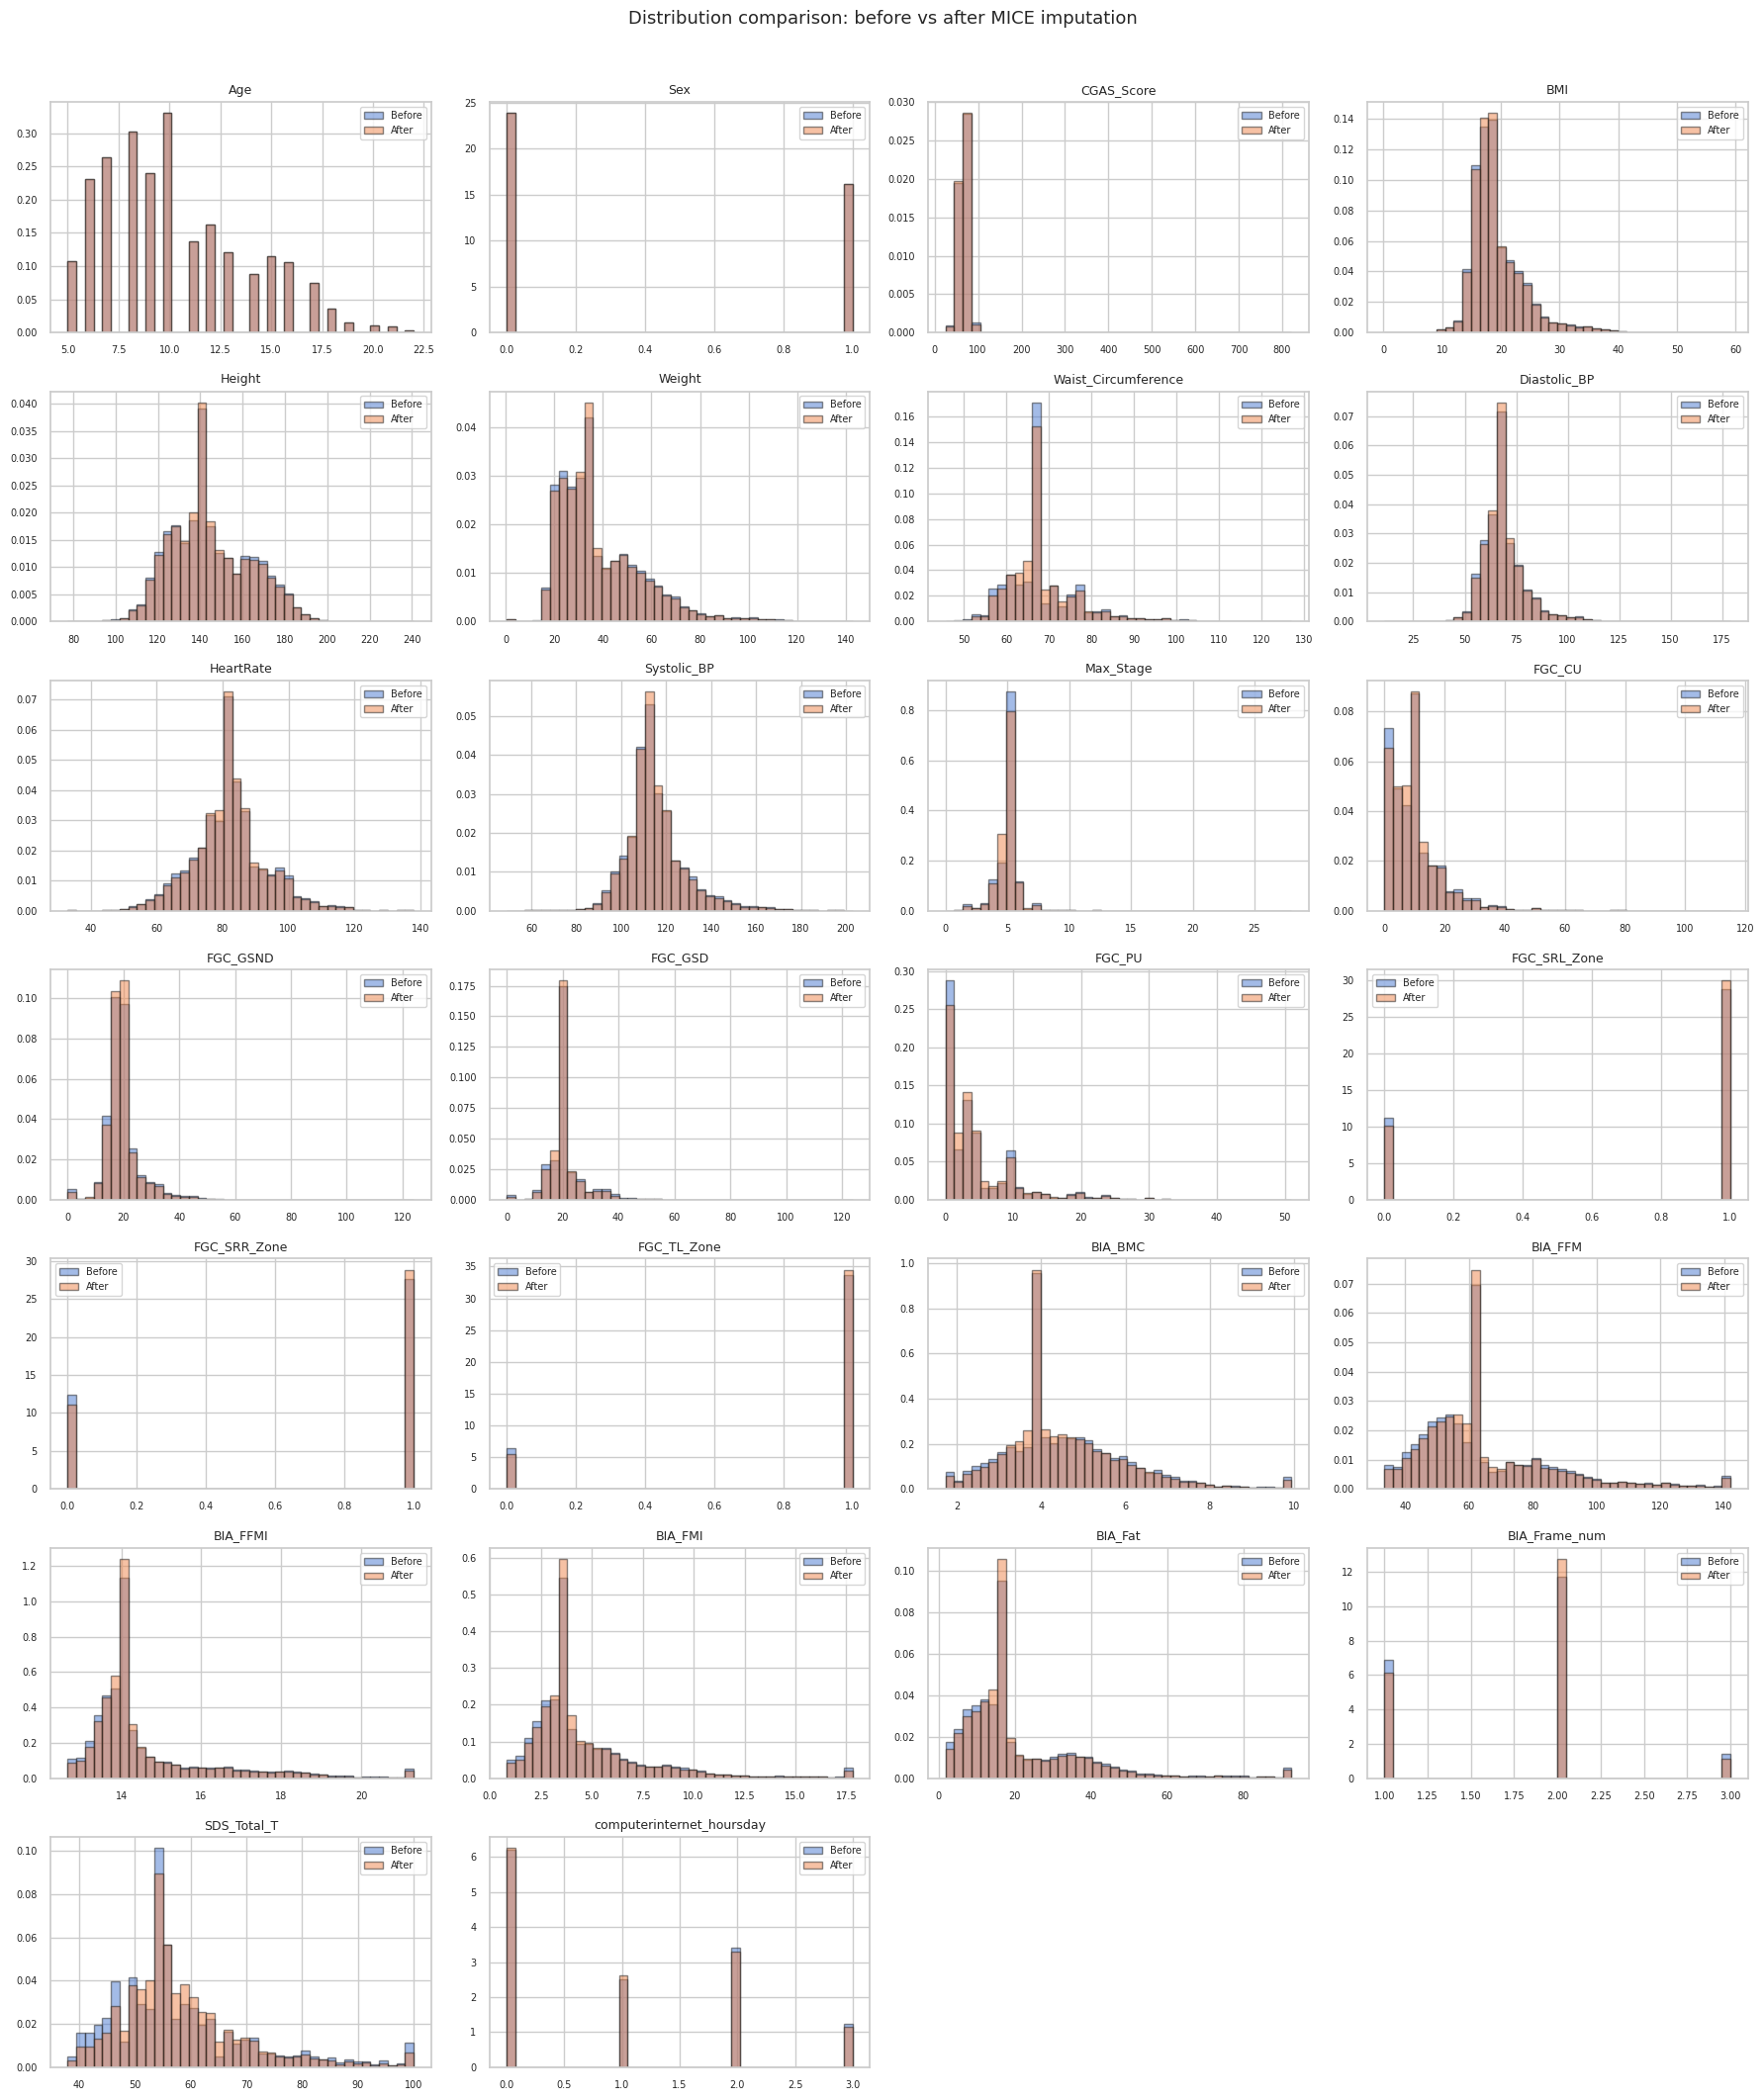

In [24]:
# Compare distributions before vs after imputation for ALL columns
check_cols = [c for c in df_imputed.columns if c != "sii"]

ncols = 4
nrows = (len(check_cols) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(check_cols):
    axes[i].hist(df_clean[col].dropna(), bins=40, alpha=0.5, label="Before", density=True, edgecolor="k")
    axes[i].hist(df_imputed[col].dropna(), bins=40, alpha=0.5, label="After", density=True, edgecolor="k")
    axes[i].set_title(col.split("-")[-1], fontsize=9)
    axes[i].legend(fontsize=7)
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Distribution comparison: before vs after MICE imputation", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [25]:
# Export the imputed dataset
# Convert categoricals back to int for export
for col in categorical_cols:
    df_imputed[col] = df_imputed[col].astype(float).astype(int)

df_imputed.to_csv("../processed_data/cmi_imputed.csv", index=False)
print(f"Saved imputed dataset to processed_data/cmi_imputed.csv")
print(f"Final shape: {df_imputed.shape}")
df_imputed.describe().T

Saved imputed dataset to processed_data/cmi_imputed.csv
Final shape: (8243, 27)


,count,mean,std,min,25%,50%,75%,max
Basic_Demos-Age,8243.0,10.205386,3.565338,5.000000,7.000000,10.000000,12.000000,22.000000
Basic_Demos-Sex,8243.0,0.404100,0.490747,0.000000,0.000000,0.000000,1.000000,1.000000
CGAS-CGAS_Score,8243.0,66.480347,24.404683,25.000000,61.000000,65.000000,70.500000,821.500000
Physical-BMI,8243.0,19.250894,4.536118,0.149269,16.480827,17.937682,20.979395,59.132048
Physical-Height,8243.0,144.278121,18.527916,77.356442,130.810000,140.538200,157.480000,240.773093
Physical-Weight,8243.0,38.574427,17.350787,0.317514,26.089100,34.578830,47.808597,142.881480
Physical-Waist_Circumference,8243.0,68.253217,9.014482,45.720000,63.584667,66.040000,71.120000,127.000000
Physical-Diastolic_BP,8243.0,68.828764,10.653106,11.000000,63.000000,68.000000,72.000000,179.000000
Physical-HeartRate,8243.0,81.931781,10.937681,33.000000,76.000000,81.500000,87.000000,138.000000
Physical-Systolic_BP,8243.0,115.438655,13.392430,49.000000,108.500000,114.000000,120.000000,203.000000


---
## Step 12. Feature Scaling (Log Transform)

Many continuous features show strong positive skew, which can hurt model performance. We apply `log1p` (i.e. log(1 + x)) to continuous columns with skewness > 1 and no negative values. This handles zeros gracefully and compresses right-tailed distributions.

Excluded from log-scaling:
- Categorical/ordinal columns (Sex, Zones, Frame, internet hours, target)
- `CGAS_Score` (bounded psychological scale 1–100, log transform not meaningful)

In [26]:
# Identify columns to log-scale: continuous, skew > 1, min >= 0, not CGAS
categorical_cols_final = [
    "Basic_Demos-Sex", "Basic_Demos-Age",
    "FGC-FGC_SRL_Zone", "FGC-FGC_SRR_Zone", "FGC-FGC_TL_Zone",
    "BIA-BIA_Frame_num",
    "PreInt_EduHx-computerinternet_hoursday", "sii",
]
skip_cols = categorical_cols_final + ["CGAS-CGAS_Score"]

continuous_cols = [c for c in df_imputed.columns if c not in skip_cols]

# Select skewed columns with no negative values
log_candidates = []
for col in continuous_cols:
    sk = df_imputed[col].skew()
    mn = df_imputed[col].min()
    if abs(sk) > 1 and mn >= 0:
        log_candidates.append((col, sk))

log_candidates.sort(key=lambda x: abs(x[1]), reverse=True)

print(f"Columns selected for log1p transform ({len(log_candidates)}):\n")
print(f"{'Column':<45s}  {'Skew (before)':>13s}")
print("-" * 62)
for col, sk in log_candidates:
    print(f"{col:<45s}  {sk:>+13.2f}")

Columns selected for log1p transform (16):

Column                                         Skew (before)
--------------------------------------------------------------
Fitness_Endurance-Max_Stage                            +6.61
FGC-FGC_GSND                                           +3.43
FGC-FGC_GSD                                            +2.96
FGC-FGC_CU                                             +2.45
FGC-FGC_PU                                             +2.42
BIA-BIA_FMI                                            +2.17
BIA-BIA_FFMI                                           +2.10
BIA-BIA_Fat                                            +2.02
Physical-Waist_Circumference                           +1.95
Physical-BMI                                           +1.86
Physical-Diastolic_BP                                  +1.61
BIA-BIA_FFM                                            +1.46
Physical-Weight                                        +1.39
SDS-SDS_Total_T                        

In [27]:
# Apply log1p and compare skewness before vs after
log_cols = [col for col, _ in log_candidates]

skew_before = df_imputed[log_cols].skew()
df_imputed[log_cols] = np.log1p(df_imputed[log_cols])
skew_after = df_imputed[log_cols].skew()

comparison = pd.DataFrame({
    "skew_before": skew_before,
    "skew_after": skew_after,
    "reduction": (skew_before.abs() - skew_after.abs()).round(2),
}).sort_values("skew_before", key=abs, ascending=False)

print("Skewness before vs after log1p transform:\n")
print(comparison.to_string())

Skewness before vs after log1p transform:

                              skew_before  skew_after  reduction
Fitness_Endurance-Max_Stage      6.605498   -1.244636       5.36
FGC-FGC_GSND                     3.426559   -3.724580      -0.30
FGC-FGC_GSD                      2.959969   -3.723802      -0.76
FGC-FGC_CU                       2.451884   -0.789186       1.66
FGC-FGC_PU                       2.417281    0.118918       2.30
BIA-BIA_FMI                      2.169899    0.641108       1.53
BIA-BIA_FFMI                     2.101262    1.828279       0.27
BIA-BIA_Fat                      2.017058   -0.018375       2.00
Physical-Waist_Circumference     1.948935    1.253741       0.70
Physical-BMI                     1.864129    0.403150       1.46
Physical-Diastolic_BP            1.606218    0.157519       1.45
BIA-BIA_FFM                      1.458024    0.613708       0.84
Physical-Weight                  1.389467   -0.040535       1.35
SDS-SDS_Total_T                  1.319017    0.

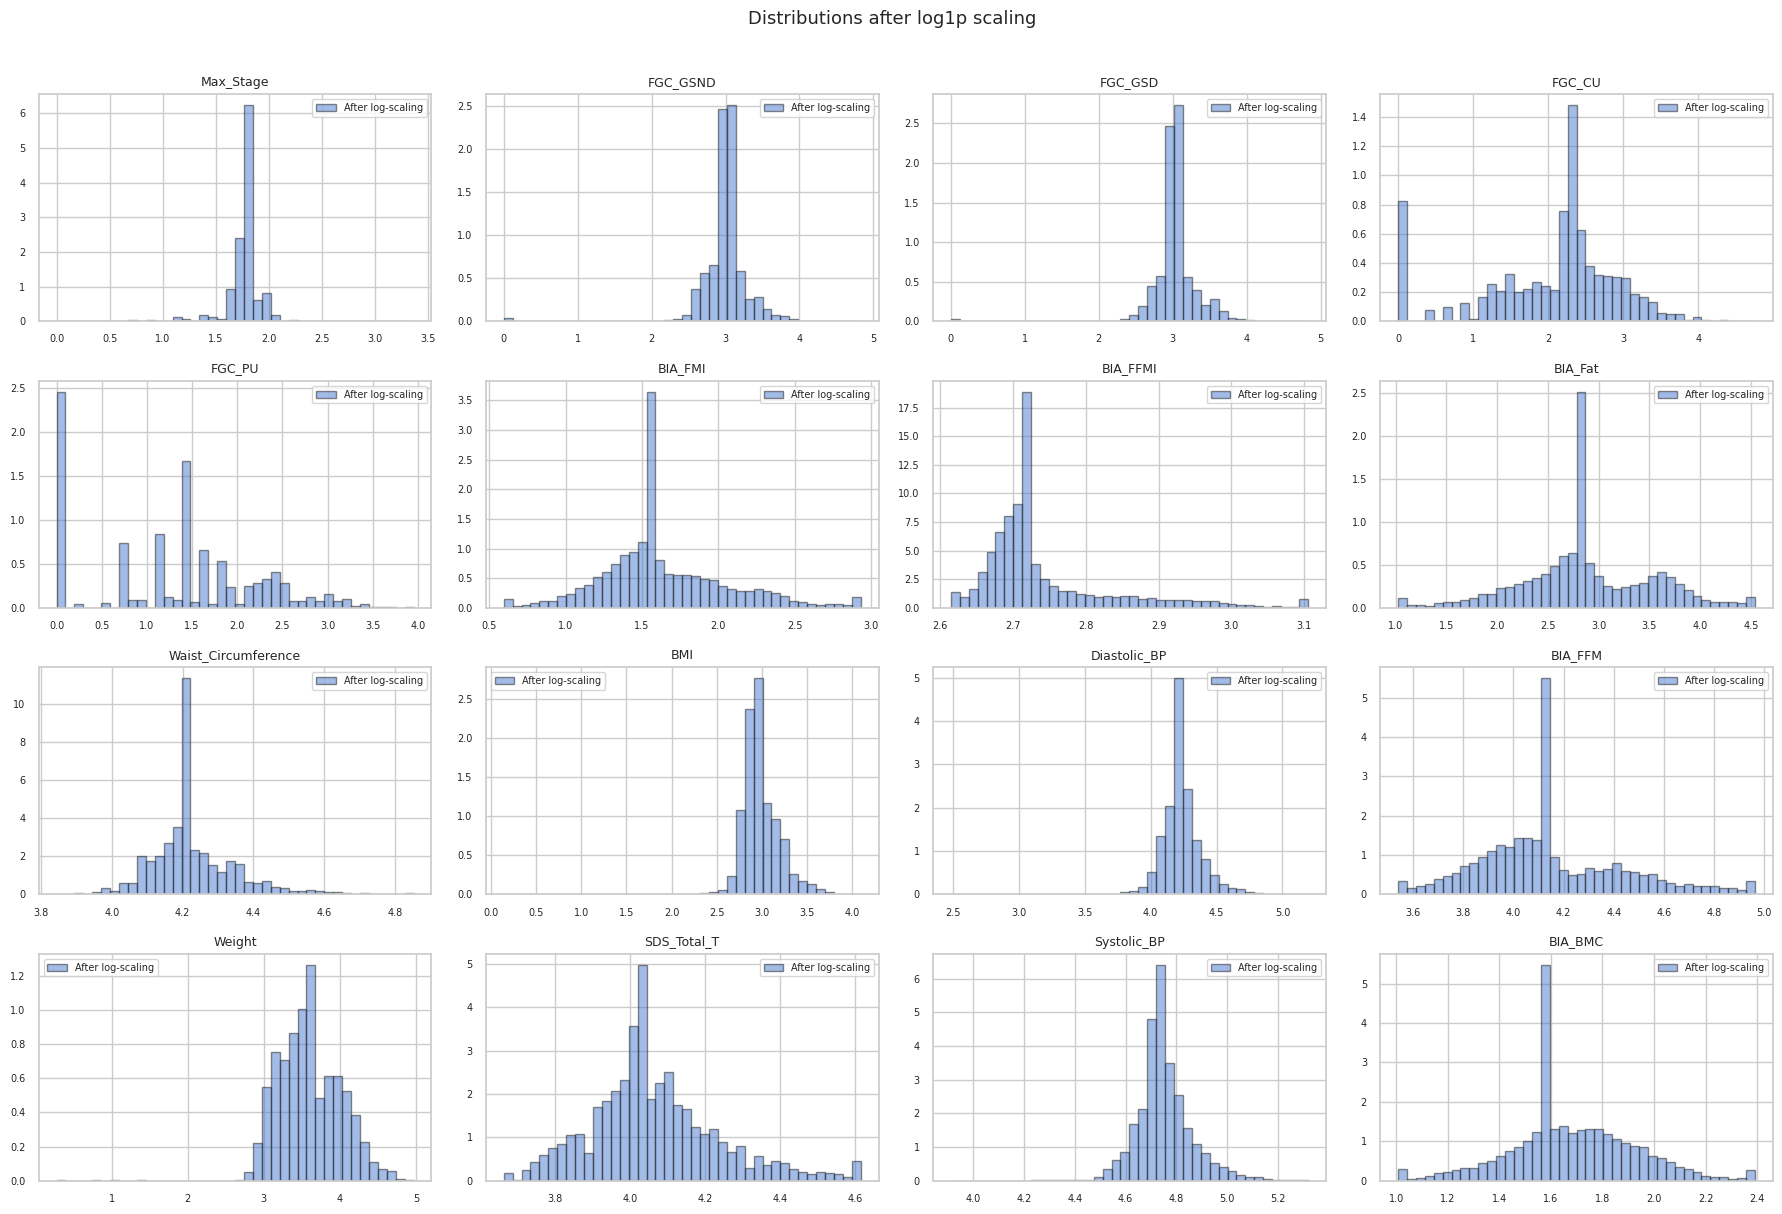

In [30]:
# Visual comparison: distributions before vs after log1p
ncols = 4
nrows = (len(log_cols) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(log_cols):
    # Reconstruct original via expm1 for overlay
    original = np.expm1(df_imputed[col])
    axes[i].hist(df_imputed[col], bins=40, alpha=0.5, label="After log-scaling", density=True, edgecolor="k")
    axes[i].set_title(col.split("-")[-1], fontsize=9)
    axes[i].legend(fontsize=7)
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Distributions after log1p scaling", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [31]:
# Re-export the final dataset with log-scaled features
df_imputed.to_csv("../processed_data/cmi_imputed.csv", index=False)
print(f"Saved final dataset (with log1p scaling) to processed_data/cmi_imputed.csv")
print(f"Final shape: {df_imputed.shape}")
print(f"\nLog-transformed columns ({len(log_cols)}):")
for col in log_cols:
    print(f"  {col}")


Saved final dataset (with log1p scaling) to processed_data/cmi_imputed.csv
Final shape: (8243, 27)

Log-transformed columns (16):
  Fitness_Endurance-Max_Stage
  FGC-FGC_GSND
  FGC-FGC_GSD
  FGC-FGC_CU
  FGC-FGC_PU
  BIA-BIA_FMI
  BIA-BIA_FFMI
  BIA-BIA_Fat
  Physical-Waist_Circumference
  Physical-BMI
  Physical-Diastolic_BP
  BIA-BIA_FFM
  Physical-Weight
  SDS-SDS_Total_T
  Physical-Systolic_BP
  BIA-BIA_BMC
